# PCA

Code de Damien

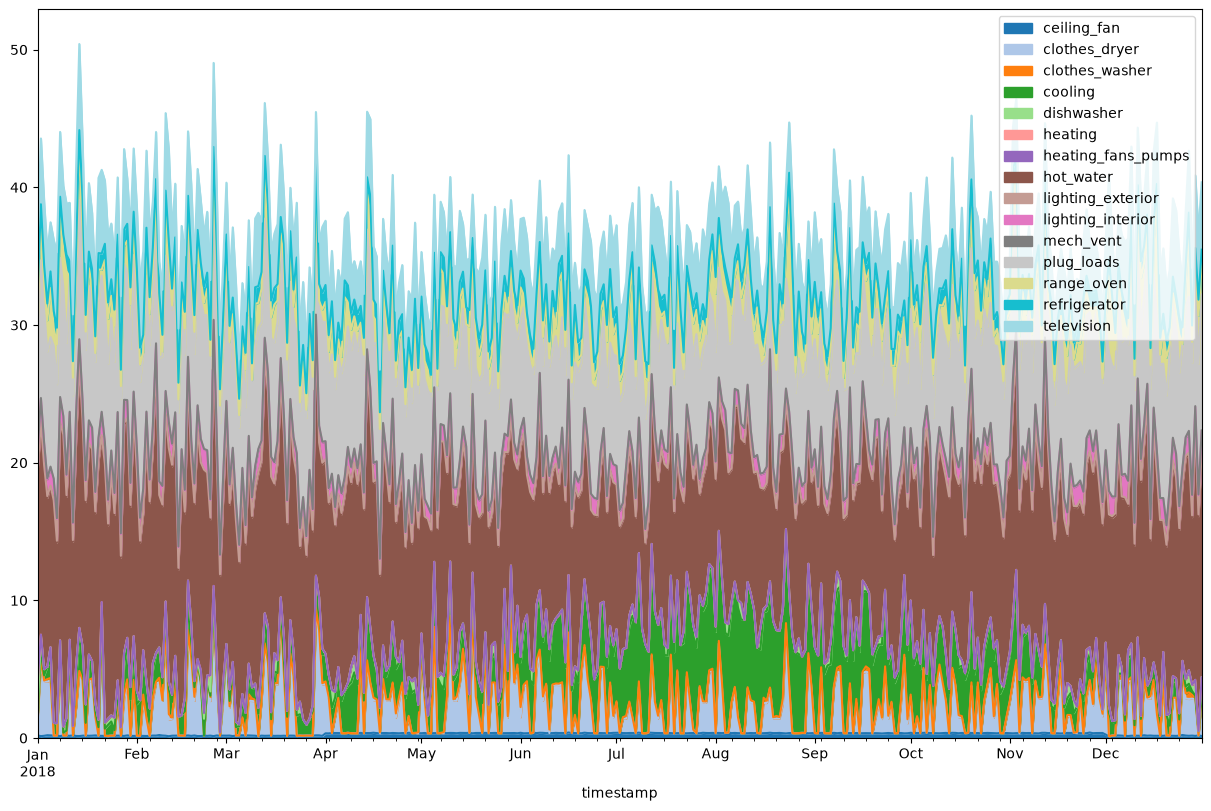

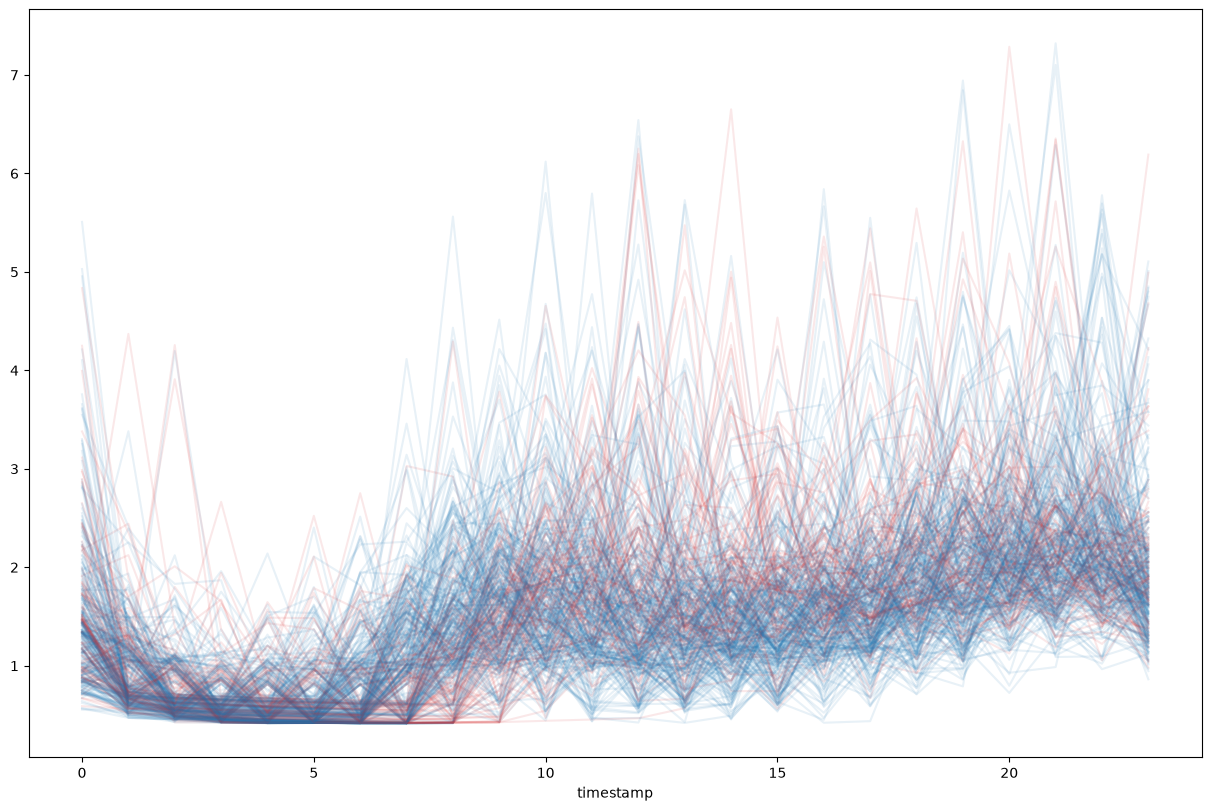

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

df = (
     pd.read_parquet("C:/Users/eassoumou1/FlexiMax/data/raw/100276-0.parquet")
       .assign(timestamp=lambda x: x["timestamp"] - pd.Timedelta("15m"))
       .set_index("timestamp")
       .loc[:, lambda x:
x.columns.str.match(r"out\.electricity\..*\.energy_consumption\.\.kwh")]
       .loc[:, lambda x: x.ne(0).any(axis=0)]
       .rename(columns=lambda x: x[16:-24])
       .drop(columns="net")
)

dfh = df.resample("h").sum()
dfd = dfh.resample("D").sum()

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
dfd.drop(columns="total").plot(ax=ax, kind="area", cmap="tab20")
plt.legend(loc="upper right")
plt.show()
plt.close(fig)

piv = dfh.pivot_table(index=dfh.index.normalize(),
columns=dfh.index.hour, values="total")
cmap = (piv.index.day_of_week // 5).map({0: "tab:blue", 1: "tab:red"})
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
piv.T.plot(ax=ax, color=cmap, alpha=0.1, legend=False)
plt.show()

In [3]:
piv

timestamp,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.85191,1.01072,0.96792,0.42196,0.41709,0.41864,0.41697,1.86916,2.25076,1.23566,...,1.11590,2.82703,2.09999,1.69789,2.37634,2.60933,3.81705,1.89853,2.41133,2.19863
2018-01-02,1.34509,0.83864,1.71675,0.45308,0.91959,1.32005,0.88697,1.74683,4.30753,1.73265,...,3.71940,1.31273,1.73931,1.42297,2.01354,2.22964,2.05833,2.08814,1.76709,1.90975
2018-01-03,5.50700,1.30829,1.03653,0.46018,0.83790,0.42120,0.41729,0.41667,0.43263,2.77029,...,1.18832,0.99422,0.96424,2.40433,1.55478,1.52530,1.52446,1.95708,2.46375,2.29523
2018-01-04,1.23420,0.81508,0.48686,0.42345,0.41876,0.81407,0.41680,0.41600,0.61370,3.44364,...,1.00649,1.48069,4.72198,1.92036,1.48928,1.22818,1.28146,1.68478,2.24787,2.04915
2018-01-05,1.68483,1.37109,0.51716,0.42852,0.56240,0.79099,0.41729,0.41673,0.41966,0.81665,...,1.25091,1.10084,5.09824,2.92324,2.87783,3.02834,2.71892,2.36324,1.93175,1.87243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,1.63688,1.23246,0.94818,0.84775,0.43868,0.43557,1.66866,0.42177,1.13393,0.43123,...,4.12175,1.05657,1.78638,1.49027,1.28171,1.78668,1.79192,3.25935,2.33994,2.84959
2018-12-28,1.43451,0.77659,1.10844,0.42339,0.41863,0.42046,0.98125,0.41534,1.20261,0.62333,...,1.25186,1.02911,1.25934,2.09075,2.02090,2.32283,1.65597,1.70651,2.69610,4.66663
2018-12-29,1.98611,0.71051,0.48861,0.85784,0.67414,1.78830,1.56078,0.41664,0.41883,0.99383,...,2.29803,2.00084,2.35659,1.34824,3.77822,2.52994,3.47225,2.14704,1.42848,1.79070
